# Fraud Detection — Model Training

Orchestrates the full Layer 2 pipeline:
`load → feature engineering → prep → split → train → evaluate → save`

All logic lives in `src/features.py` and `src/model.py`.
This notebook is for running and observing, not for defining functions.

In [1]:
import sys
sys.path.append('..')   # so 'src' is importable from notebooks/

import pandas as pd
import lightgbm as lgb
from src.features import build_features
from src.model import (
    prepare_features,
    time_based_split,
    select_features,
    tune_hyperparameters,
    train,
    evaluate,
    plot_feature_importance,
    save_model,
    LABEL,
)

DATA_DIR = '../data'

## 1. Load raw data

In [2]:
df = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
print(f'Loaded: {df.shape}')

Loaded: (590540, 394)


## 2. Feature engineering

Adds `card_addr`, `velocity_1h`, `hist_mean_amt`, `amt_deviation`.

In [3]:
df = build_features(df)
print(f'After feature engineering: {df.shape}')
df[['velocity_1h', 'hist_mean_amt', 'amt_deviation']].describe()

After feature engineering: (590540, 398)


,velocity_1h,hist_mean_amt,amt_deviation
count,590540.000000,590540.000000,590540.000000
mean,0.645044,129.827416,5.199761
std,4.687785,124.664974,222.772300
min,0.000000,0.424000,-4019.970000
25%,0.000000,75.000000,-62.765317
50%,0.000000,108.500000,-18.915201
75%,0.000000,144.302382,13.422031
max,191.000000,5279.950000,31801.478407


## 3. Prepare feature matrix

In [4]:
df = prepare_features(df)
print(f'After prep: {df.shape}')

Dropping 0 columns with >99% missing
After prep: (590540, 396)


## 4. Time-based split

Train on the first 80% of transactions chronologically, test on the last 20%.
Note: fraud rate may differ between splits — this is expected and realistic.

In [5]:
train_df, test_df = time_based_split(df)

FEATURES = [c for c in train_df.columns if c != LABEL]
X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test,  y_test  = test_df[FEATURES],  test_df[LABEL]

print(f'Train : {X_train.shape}  |  fraud rate: {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}   |  fraud rate: {y_test.mean():.2%}')

Train : (472432, 395)  |  fraud rate: 3.51%
Test  : (118108, 395)   |  fraud rate: 3.44%


## 5. Train baseline LightGBM

Baseline model trained on all features. Used by `select_features` in the next step
to identify which features LightGBM actually used (importance > 0).

In [13]:
model = train(X_train, y_train, X_test, y_test)

scale_pos_weight: 27.5  (neg=455,833, pos=16,599)


## 6. Feature selection

Drop features the baseline model never used (importance == 0).
Reduces noise and speeds up hyperparameter search.

In [ ]:
X_train_f, X_test_f, features_f = select_features(model, X_train, X_test)

print(f'Features before : {X_train.shape[1]}')
print(f'Features after  : {X_train_f.shape[1]}  ({X_train.shape[1] - X_train_f.shape[1]} dropped)')

## 7. Hyperparameter tuning

Optuna searches over `num_leaves`, `learning_rate`, `min_child_samples`,
`feature_fraction`, `bagging_fraction` using 3-fold `TimeSeriesSplit`.
Reduce `n_trials` for a faster run during development.

In [15]:
best_params = tune_hyperparameters(X_train_f, y_train, n_trials=50)

  0%|          | 0/50 [00:00<?, ?it/s]

Best PR-AUC : 0.5798
Best params : {'num_leaves': 273, 'learning_rate': 0.03981071630267616, 'min_child_samples': 169, 'feature_fraction': 0.7549782138403553, 'bagging_fraction': 0.8960575517195016}


## 8. Train final model

Combines `best_params` from tuning with fixed settings (`scale_pos_weight`,
early stopping). Built inline because `train()` hardcodes its own params.

In [16]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

model_tuned = lgb.LGBMClassifier(
    **best_params,
    scale_pos_weight=neg / pos,
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
)
model_tuned.fit(
    X_train_f, y_train,
    eval_set=[(X_test_f, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

LGBMClassifier(bagging_fraction=0.8960575517195016,
               feature_fraction=0.7549782138403553,
               learning_rate=0.03981071630267616, min_child_samples=169,
               n_estimators=500, n_jobs=-1, num_leaves=273, random_state=42,
               scale_pos_weight=np.float64(27.46147358274595))

## 9. Evaluate — PR-AUC & ROC-AUC

PR-AUC  : 0.3314
ROC-AUC : 0.8585


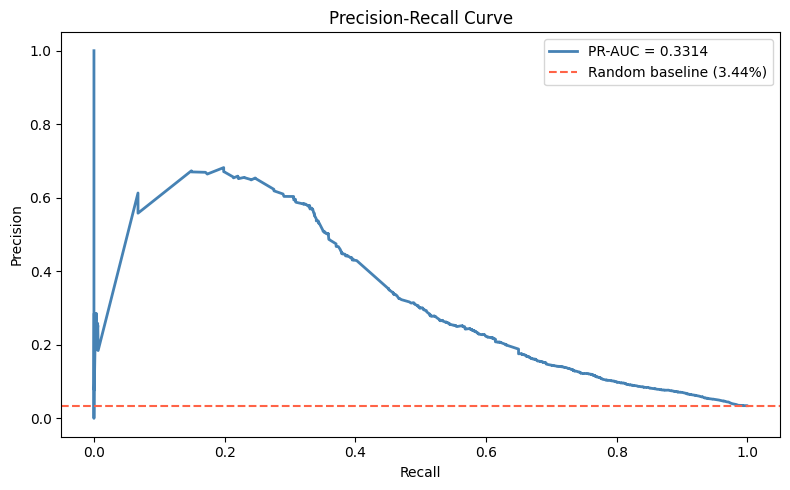

In [17]:
metrics = evaluate(model_tuned, X_test_f, y_test)

## 10. Feature importance

Check where `velocity_1h` and `amt_deviation` rank — did the engineered features add signal?

       feature  importance
         card2          63
TransactionAmt          45
 TransactionDT          45
         addr1          42
            D2          38
           D10          32
            C2          25
           C13          24
           C14          19
            D3          17
            C6          15
            C1          14
          V310          13
            D8          12
            D1          12
           V87          12
 hist_mean_amt          11
           C11          11
           V76          10
         card3           9


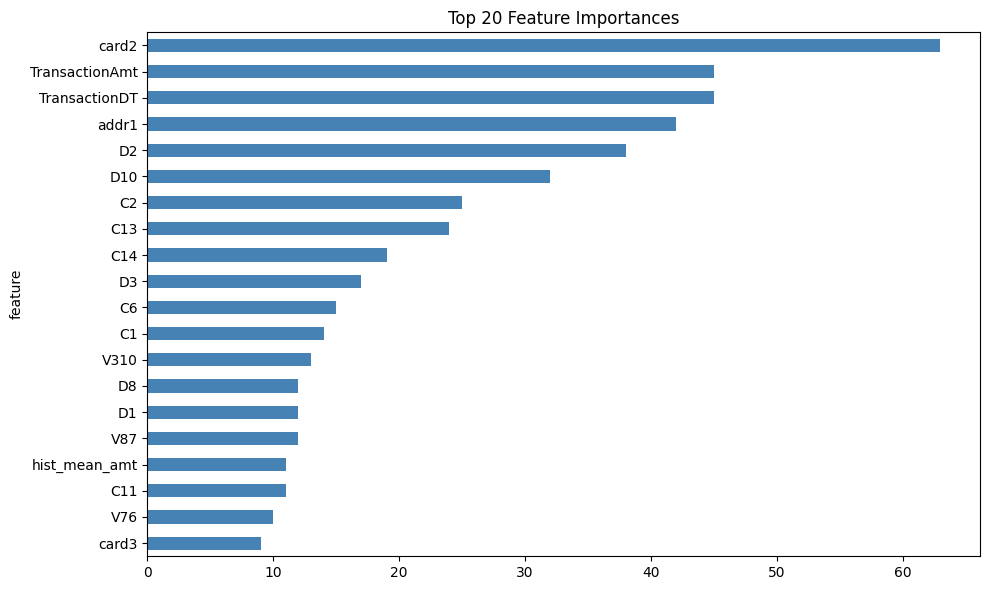

In [18]:
plot_feature_importance(model_tuned, features_f)

## 11. Save model

Persists to `models/lgbm_fraud.pkl` — loaded by the FastAPI layer in Layer 3.

In [19]:
save_model(model_tuned)

Model saved to /Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/notebooks/../models/lgbm_fraud.pkl
